# 预测问题

## 1. 灰度系统预测

In [1]:
from numpy.ma.extras import average

# 例 1.1
x0 = [9, 9, 9, 9, 8, 9, 9]
x1 = [8, 9, 8, 7, 5, 2, 9]
x2 = [7, 8, 7, 5, 7, 3, 8]
x3 = [9, 7, 9, 6, 6, 4, 7]
x4 = [6, 8, 8, 8, 4, 3, 6]
x5 = [8, 6, 6, 9, 8, 3, 8]
x6 = [8, 9, 5, 7, 6, 4, 8]
X = [x1, x2, x3, x4, x5, x6]
Y = []
for x in X:
    temp = [abs(x0[i] - x[i]) for i in range(len(x))]
    Y.append(temp)
print(Y)
max_value = max([max(y) for y in Y])
min_value = min([min(y) for y in Y])
rou = 0.5
zeta = []
for i, y in enumerate(Y):
    temp = [(min_value + rou * max_value) / (Y[i][j] + rou * max_value) for j in range(len(y))]
    zeta.append(temp)
print(zeta)
r = [average(z) for z in zeta]
print(r)

[[1, 0, 1, 2, 3, 7, 0], [2, 1, 2, 4, 1, 6, 1], [0, 2, 0, 3, 2, 5, 2], [3, 1, 1, 1, 4, 6, 3], [1, 3, 3, 0, 0, 6, 1], [1, 0, 4, 2, 2, 5, 1]]
[[0.7777777777777778, 1.0, 0.7777777777777778, 0.6363636363636364, 0.5384615384615384, 0.3333333333333333, 1.0], [0.6363636363636364, 0.7777777777777778, 0.6363636363636364, 0.4666666666666667, 0.7777777777777778, 0.3684210526315789, 0.7777777777777778], [1.0, 0.6363636363636364, 1.0, 0.5384615384615384, 0.6363636363636364, 0.4117647058823529, 0.6363636363636364], [0.5384615384615384, 0.7777777777777778, 0.7777777777777778, 0.7777777777777778, 0.4666666666666667, 0.3684210526315789, 0.5384615384615384], [0.7777777777777778, 0.5384615384615384, 0.5384615384615384, 1.0, 1.0, 0.3684210526315789, 0.7777777777777778], [0.7777777777777778, 1.0, 0.4666666666666667, 0.6363636363636364, 0.6363636363636364, 0.4117647058823529, 0.7777777777777778]]
[np.float64(0.7233877233877234), np.float64(0.6344497607655503), np.float64(0.6941881647764001), np.float64(0.606

In [2]:
# 例 1.2
import numpy as np
x0 = [71.1, 72.4, 72.4, 72.1, 71.4, 72.0, 71.6]
n = len(x0)
temp = x0[0]
x1 = [temp]
for i in range(1, n):
    temp += x0[i]
    x1.append(temp)
print(x1)
alpha = 0.5
z1 = [x1[0]]
for i in range(1, n):
    z1.append((1 - alpha) * x1[i - 1] + alpha * x1[i])
print(z1)
Y = np.array(x0[1:])
B = np.array([[-z1[i], 1] for i in range(1, n)])
u = np.linalg.inv(B.T @ B) @ B.T @ Y
a = u[0]
b = u[1]
print(a, b)
left = np.exp(-2 / (n + 1))
right = np.exp(2 / (n + 1))
# 数据检验
lam = []
for i in range(1, n):
    lam.append(x0[i - 1] / x0[i])
print(lam)
is_satisfied = True
for i in range(1, n):
    if lam[i - 1] < left or lam[i - 1] > right:
        is_satisfied = False
        break
print(is_satisfied)

[71.1, 143.5, 215.9, 288.0, 359.4, 431.4, 503.0]
[71.1, 107.3, 179.7, 251.95, 323.7, 395.4, 467.2]
0.0023437864785236795 72.65726960367881
[0.9820441988950275, 1.0, 1.0041608876560335, 1.0098039215686272, 0.9916666666666667, 1.005586592178771]
True


In [3]:
# 预测
def predict(t):
    temp = b / a
    return (x0[0] - temp) * np.exp(-a * (t - 1)) + temp

x1_pred = [x1[0]]
for i in range(1, n):
    x1_pred.append(predict(i + 1))
x0_pred = [x0[0]]
for i in range(1, n):
    x0_pred.append(x1_pred[i] - x1_pred[i - 1])
print(x0_pred)
# 检验预测值
epsilon = [(x0[i] - x0_pred[i]) / x0[i] for i in range(n)]
print(epsilon)
rou = [1 - (1 - 0.5 * a) / (1 + 0.5 * a) * lam[i] for i in range(n - 1)]
print(rou)

[71.1, np.float64(72.40574144042913), np.float64(72.23623656189375), np.float64(72.06712850138865), np.float64(71.89841632994285), np.float64(71.73009912077396), np.float64(71.56217594924965)]
[0.0, np.float64(-7.930166338562697e-05), np.float64(0.0022619259406941746), np.float64(0.0004559153760241683), np.float64(-0.006980620867546802), np.float64(0.003748623322583929), np.float64(0.0005282688652282807)]
[np.float64(0.020254808828047643), np.float64(0.0023410430260286663), np.float64(-0.0018101038129756386), np.float64(-0.007439927140382663), np.float64(0.010654867667478363), np.float64(-0.0032324707000830344)]


In [4]:
# 例 1.3 SARS 预测
sales = [   # 商品零售额
    [83.0, 79.8, 78.1, 85.1, 86.6, 88.2, 90.3, 86.7, 93.3, 92.5, 90.9, 96.9],
    [101.7, 85.1, 87.8, 91.6, 93.4, 94.5, 97.4, 99.5, 104.2, 102.3, 101.0, 123.5],
    [92.2, 114.0, 93.3, 101.0, 103.5, 105.2, 109.5, 109.2, 109.6, 111.2, 121.7, 131.3],
    [105.0, 125.7, 106.6, 116.0, 117.6, 118.0, 121.7, 118.7, 120.2, 127.8, 121.8, 121.9],
    [139.3, 129.5, 122.5, 124.5, 135.7, 130.8, 138.7, 133.7, 136.8, 138.9, 129.6, 133.7],
    [137.5, 135.3, 133.0, 133.4, 142.8, 141.6, 142.9, 147.3, 159.6, 162.1, 153.5, 155.9],
    [163.2, 159.7, 158.4, 145.2, 124, 144.1, 157, 162.6, 171.8, 180.7, 173.5, 176.5],
]
tourists = [    # 海外游客人数
    [9.4, 11.3, 16.8, 19.8, 20.3, 18.8, 20.9, 24.9, 24.7, 24.3, 19.4, 18.6],
    [9.6, 11.7, 15.8, 19.9, 19.5, 17.8, 17.8, 23.3, 21.4, 24.5, 20.1, 15.9],
    [10.1, 12.9, 17.7, 21.0, 21.0, 20.4, 21.9, 25.8, 29.3, 29.8, 23.6, 16.5],
    [11.4, 26.0, 19.6, 25.9, 27.6, 24.3, 23.0, 27.8, 27.3, 28.5, 32.8, 18.5],
    [11.5, 26.4, 20.4, 26.1, 28.9, 28.0, 25.2, 30.8, 28.7, 28.1, 22.2, 20.7],
    [13.7, 29.7, 23.1, 28.9, 29.0, 27.4, 26.0, 32.2, 31.4, 32.6, 29.2, 22.9],
    [15.4, 17.1, 23.5, 11.6, 1.78, 2.61, 8.8, 16.2, 20.1, 24.9, 26.5, 21.8],
]
service = [ # 服务业累计数据
    [96, 144, 194, 276, 383, 466, 554, 652, 747, 832, 972],
    [111, 169, 235, 400, 459, 565, 695, 805, 881, 1011, 1139],
    [151, 238, 335, 425, 541, 641, 739, 866, 975, 1087, 1238],
    [164, 263, 376, 531, 600, 711, 913, 1038, 1173, 1296, 1497],
    [182, 318, 445, 576, 708, 856, 1000, 1145, 1292, 1435, 1667],
    [216, 361, 504, 642, 818, 979, 1142, 1305, 1479, 1644, 1920],
    [241, 404, 584, 741, 923, 1114, 1298, 1492, 1684, 1885, 2218],
]

In [5]:
x0 = np.array(sales)[:, 0]
n = len(x0)
lam = []
for i in range(1, n):
    lam.append(x0[i - 1] / x0[i])
print(lam)
is_satisfied = True
left = np.exp(-2 / (n + 1))
right = np.exp(2 / (n + 1))
print(left, right)
for i in lam:
    if i < left or i > right:
        is_satisfied = False
        break
print(is_satisfied)

[np.float64(0.816125860373648), np.float64(1.1030368763557483), np.float64(0.8780952380952382), np.float64(0.7537688442211055), np.float64(1.0130909090909093), np.float64(0.8425245098039216)]
0.7788007830714049 1.2840254166877414
False


In [6]:
x0 = [average(i) for i in sales]
n = len(x0)
lam = []
for i in range(1, n):
    lam.append(x0[i - 1] / x0[i])
print(lam)
is_satisfied = True
left = np.exp(-2 / (n + 1))
right = np.exp(2 / (n + 1))
print(left, right)
for i in lam:
    if i < left or i > right:
        is_satisfied = False
        break
print(is_satisfied)

[np.float64(0.8895093062605752), np.float64(0.9080433279557502), np.float64(0.9160450387051373), np.float64(0.891635816025601), np.float64(0.913347469769041), np.float64(0.9103667762299786)]
0.7788007830714049 1.2840254166877414
True


In [7]:
x1 = [x0[0]]
temp = x0[0]
for i in range(1, n):
    temp += x0[i]
    x1.append(temp)
print(x1)
alpha = 0.5
z1 = [x1[0]]
for i in range(1, n):
    z1.append((1 - alpha) * x1[i - 1] + alpha * x1[i])
print(z1)
Y = np.array(x0[1:])
B = np.array([[-z1[i], 1] for i in range(1, n)])
u = np.linalg.inv(B.T @ B) @ B.T @ Y
a = u[0]
b = u[1]
print(a, b)

[np.float64(87.61666666666666), np.float64(186.11666666666667), np.float64(294.5916666666667), np.float64(413.0083333333334), np.float64(545.8166666666667), np.float64(691.225), np.float64(850.95)]
[np.float64(87.61666666666666), np.float64(136.86666666666667), np.float64(240.35416666666669), np.float64(353.80000000000007), np.float64(479.4125), np.float64(618.5208333333334), np.float64(771.0875000000001)]
-0.09730834410907352 85.0545973559007


In [8]:
def predict(t):
    temp = b / a
    return (x0[0] - temp) * np.exp(-a * (t - 1)) + temp

x1_pred = [x1[0]]
for i in range(1, n):
    x1_pred.append(predict(i + 1))
x0_pred = [x0[0]]
for i in range(1, n):
    x0_pred.append(x1_pred[i] - x1_pred[i - 1])
print(x0_pred)

[np.float64(87.61666666666666), np.float64(98.28485642032184), np.float64(108.32958625709625), np.float64(119.40088927277748), np.float64(131.6036814291458), np.float64(145.05360111796813), np.float64(159.87810499525108)]


In [9]:
epsilon = [(x0[i] - x0_pred[i]) / x0[i] for i in range(n)]
print(epsilon)
rou = [1 - (1 - 0.5 * a) / (1 + 0.5 * a) * lam[i] for i in range(n - 1)]
print(rou)

[np.float64(0.0), np.float64(0.0021841987784584323), np.float64(0.0013405277059576478), np.float64(-0.008311520952378366), np.float64(0.00907060478775805), np.float64(0.002439559048875259), np.float64(-0.0009585537345505346)]
[np.float64(0.019507294097302896), np.float64(-0.0009224787620243369), np.float64(-0.009742643957934005), np.float64(0.017163274423800057), np.float64(-0.006769154364406171), np.float64(-0.0034835807869153523)]


## 2. 回归分析

### 2.1 一元线性回归

                            OLS Regression Results                            
Dep. Variable:                   不良贷款   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     56.75
Date:                Tue, 14 Jan 2025   Prob (F-statistic):           1.18e-07
Time:                        19:27:13   Log-Likelihood:                -51.508
No. Observations:                  25   AIC:                             107.0
Df Residuals:                      23   BIC:                             109.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8295      0.723     -1.147      0.2

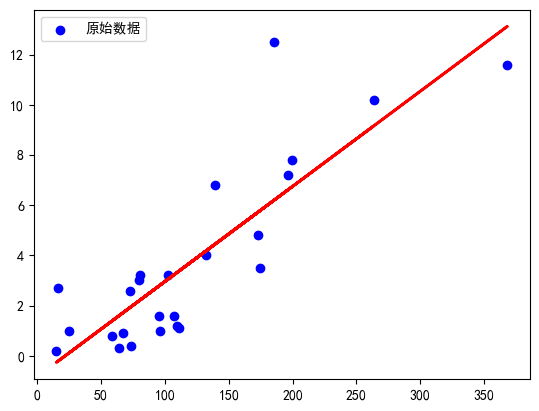

In [10]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 一元线性回归
data = pd.read_excel("./data/linear_regression.xlsx")
y = data.iloc[:, 0]     # 因变量
x = data.iloc[:, 1]     # 自变量
x = sm.add_constant(x)  # 添加常数项
model = sm.OLS(y, x, hasconst=True)    # 构建最小二乘模型
result = model.fit()
print(result.summary())

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
pred = result.predict()
x = data.iloc[:, 1]
plt.scatter(x, y, color='blue', label='原始数据')
plt.plot(x, pred, color='red', linewidth=2)
plt.legend()
plt.show()

### 2.2 多元线性回归

In [11]:
# 多元线性回归
y = data.iloc[:, 0]
x = data.iloc[:, 1:]
x = sm.add_constant(x)
model = sm.OLS(y, x, hasconst=True)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   不良贷款   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     19.70
Date:                Tue, 14 Jan 2025   Prob (F-statistic):           1.04e-06
Time:                        19:27:13   Log-Likelihood:                -47.082
No. Observations:                  25   AIC:                             104.2
Df Residuals:                      20   BIC:                             110.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0216      0.782     -1.306      0.2

### 2.3 多项式回归

In [12]:
# 例：多项式回归
y = [100, 75, 80, 70, 50, 65, 90, 100, 110, 60]             # 需求量
x1 = [1000, 600, 1200, 500, 300, 400, 1300, 1100, 1300, 300]# 收入
x2 = [5, 7, 6, 6, 8, 7, 5, 4, 3, 9]                         # 价格
x1_sq = [i ** 2 for i in x1]
x2_sq = [i ** 2 for i in x2]
data = pd.DataFrame({'需求量': y, '收入': x1, '价格': x2, '收入^2': x1_sq, '价格^2': x2_sq})
y = data.iloc[:, 0]
x = data.iloc[:, 1:]
x = sm.add_constant(x)
model = sm.OLS(y, x, hasconst=True)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    需求量   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     40.67
Date:                Tue, 14 Jan 2025   Prob (F-statistic):           0.000526
Time:                        19:27:13   Log-Likelihood:                -25.845
No. Observations:                  10   AIC:                             61.69
Df Residuals:                       5   BIC:                             63.20
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        110.5313     20.723      5.334      0.0

D:\codes\Modelization\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


### 2.4 逐步回归

In [13]:
import pandas as pd
import toad


data = pd.read_excel('./data/step_wise.xlsx')
data = data.iloc[:, 1:]
result = toad.selection.stepwise(data, target="居民家庭平均每年每人消费支出")
print(result)

    居民食品花费  居民衣着消费  居民居住花费  居民文教娱乐花费  地区消费价格指数  居民家庭平均每年每人消费支出
0     7535    2639    1971      3696     106.5           24046
1     7344    1881    1854      2254     107.5           20024
2     4211    1542    1502      1204     104.1           12531
3     3856    1529    1439      1506     108.8           12212
4     5463    2730    1584      1972     109.6           17717
5     5809    2042    1433      1844     107.7           16594
6     4635    2045    1594      1643     111.0           14614
7     4687    1807    1337      1217     104.8           12984
8     9656    2111    1790      3724     106.0           26253
9     6658    1916    1437      3078     112.6           18825
10    7552    2110    1552      2997     104.5           21545
11    5815    1541    1397      1933     105.3           15012
12    7317    1634    1754      2105     104.6           18593
13    5072    1477    1174      1487     106.7           12776
14    5201    2197    1572       165     106.9         

## 3. 曲线拟合

### 3.1 多项式拟合

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

 
3.916 x + 1.211
       2
15.33 x + 9.484 x + 1.467


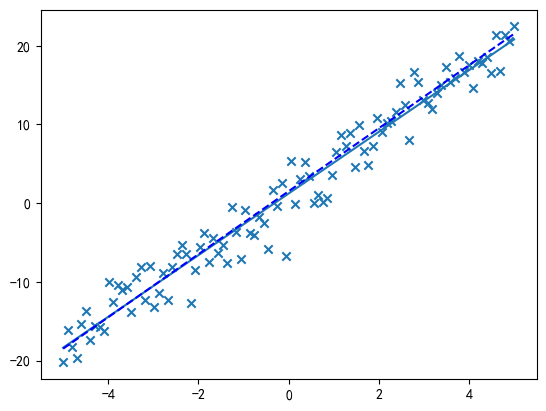

In [18]:
x = np.linspace(-5, 5, 100)
y = 4 * x + 1.5
noisy_y = y + np.random.randn(y.shape[-1]) * 2.5
coef = np.polyfit(x, noisy_y, 1)   # 线性拟合
f = np.poly1d(coef)
print(f)
print(f ** 2)
plt.plot(x, f(x))
plt.scatter(x, noisy_y, marker='x')
plt.plot(x, y, 'b--')
plt.show()

### 3.2 最小二乘拟合

In [22]:
from scipy.linalg import lstsq
from scipy.optimize import leastsq
from scipy.stats import norm

[ 0.50459421 -0.01412957] 17.08758235420643 2 [30.23732043  4.82146667]


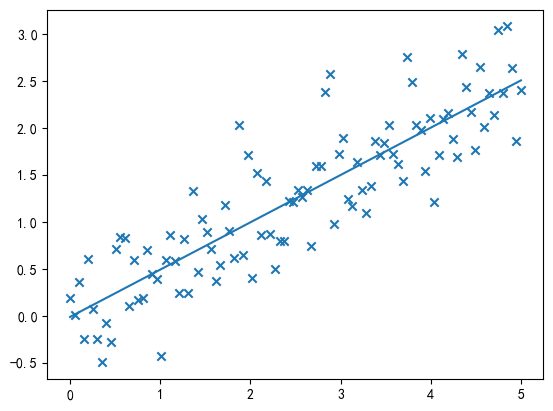

In [21]:
# 线性
x = np.linspace(0, 5, 100)
y = 0.5 * x + np.random.randn(x.shape[-1]) * 0.35
X = np.hstack((x[:, np.newaxis], np.ones((x.shape[-1], 1))))    # 添加一列 1
coef, residue, rank, s = lstsq(X, y)    # 解、残差、秩、奇异值
print(coef, residue, rank, s)

plt.scatter(x, y, marker='x')
plt.plot(x, coef @ X.T)
plt.show()

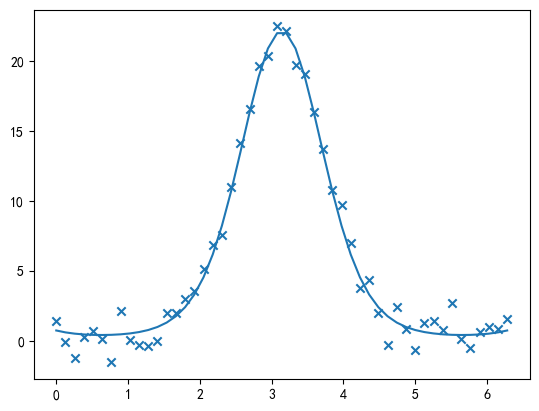

In [24]:
# 非线性
def func(x, a, b, w, phi):
    return a * np.exp(-b * np.sin(w * x + phi))

x = np.linspace(0, 2 * np.pi, 50)
y = func(x, 3, 2, 1.25, np.pi / 4)
noisy_y = y + norm.rvs(size=len(x)) * 0.8
plt.plot(x, y)
plt.scatter(x, noisy_y, marker='x')
plt.show()

[2.9082293  2.029538   1.21422566 0.90182539] 1


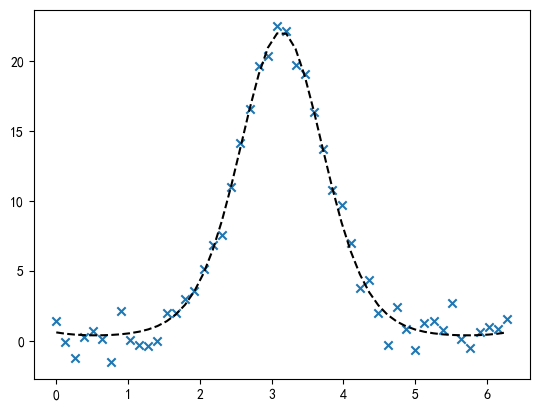

In [27]:
# 定义误差函数
def f_err(p, y, x):
    return y - func(x, *p)

coef, ret_val = leastsq(f_err, [1, 1, 1, 1], args=(noisy_y, x))
print(coef, ret_val)
plt.scatter(x, noisy_y, marker='x')
plt.plot(x, func(x, *coef), 'k--')
plt.show()

[2.90822956 2.02953791 1.21422569 0.90182528] [[ 0.31848345 -0.10810656  0.03757629 -0.11792741]
 [-0.10810656  0.03702523 -0.01256896  0.03944577]
 [ 0.03757629 -0.01256896  0.00500323 -0.01570184]
 [-0.11792741  0.03944577 -0.01570184  0.04951831]]


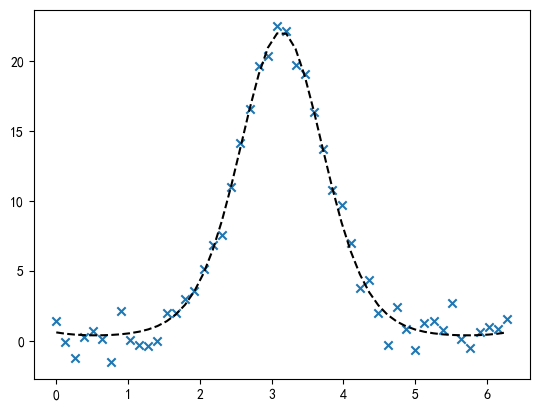

In [28]:
# 更好的做法
from scipy.optimize import curve_fit
p_est, err_est = curve_fit(func, x, noisy_y)    # 参数、参数的协方差矩阵
print(p_est, err_est)
plt.scatter(x, noisy_y, marker='x')
plt.plot(x, func(x, *p_est), 'k--')
plt.show()